Problem Statement:
A supermarket chain aims to optimize its sales and inventory management by
accurately predicting future sales for each product across its various stores.
Accurate sales predictions enable the supermarket to optimize inventory levels,
plan promotions effectively, and ensure customer satisfaction by minimizing
stock-outs and overstocking situations. As a data science intern, your task is to
develop a machine learning model to predict supermarket sales based on
historical sales data and other relevant factors

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Goal:
goal is to develop a model that can accurately forecast future
sales for each product in different supermarket store

In [2]:
supermarket=pd.read_csv('Downloads/supermarket_sales - Sheet1.csv')

In [3]:
supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
supermarket.shape

(1000, 17)

In [5]:
supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [6]:
supermarket.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [7]:
supermarket.select_dtypes(include=['object']).sum()

Invoice ID       750-67-8428226-31-3081631-41-3108123-19-117637...
Branch           ACAAACACABBBAAABAAABCBBAAABABABBBACCAACBBCBCCB...
City             YangonNaypyitawYangonYangonYangonNaypyitawYang...
Customer type    MemberNormalNormalMemberNormalNormalMemberNorm...
Gender           FemaleFemaleMaleMaleMaleMaleFemaleFemaleFemale...
Product line     Health and beautyElectronic accessoriesHome an...
Date             1/5/20193/8/20193/3/20191/27/20192/8/20193/25/...
Time             13:0810:2913:2320:3310:3718:3014:3611:3817:151...
Payment          EwalletCashCredit cardEwalletEwalletEwalletEwa...
dtype: object

In [8]:
# checking for duplicates
supermarket.duplicated().any()

False

In [9]:
supermarket.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [10]:
# columns in the population
supermarket.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [11]:
# number of unique values
supermarket.nunique()

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Total                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

In [26]:
avgspmark=supermarket['Unit price'].mean()
varspmark=supermarket['Unit price'].var()

In [12]:
# aggregation by city
supermarket.groupby('City').agg(average_unitprice=('Unit price','mean')\
,av_quantity=('Quantity','mean'),av_5perctax=('Tax 5%','mean')\
,av_total=('Total','mean'),av_grosincome=('gross income','mean')).reset_index()

,City,average_unitprice,av_quantity,av_5perctax,av_total,av_grosincome
0,Mandalay,55.659277,5.481928,15.232024,319.872506,15.232024
1,Naypyitaw,56.609024,5.582317,16.052367,337.099715,16.052367
2,Yangon,54.780853,5.467647,14.874001,312.354031,14.874001


In [45]:
# product lines and their ratings
supermarket.groupby('Product line').agg(maximum_rating=('Rating','max')\
,minimum_rating=('Rating','min')).reset_index()

,Product line,maximum_rating,minimum_rating
0,Electronic accessories,10.0,4.0
1,Fashion accessories,9.9,4.0
2,Food and beverages,9.9,4.0
3,Health and beauty,10.0,4.0
4,Home and lifestyle,9.9,4.1
5,Sports and travel,10.0,4.0


In [46]:
supermarket.groupby('Payment').agg(av_total=('Total','mean')\
,av_grossincome=('gross income','mean')\
,total_unitprice=('Unit price','sum')).reset_index()

,Payment,av_total,av_grossincome,total_unitprice
0,Cash,326.181890,15.532471,19525.09
1,Credit card,324.009878,15.429042,16916.68
2,Ewallet,318.820600,15.181933,19230.36


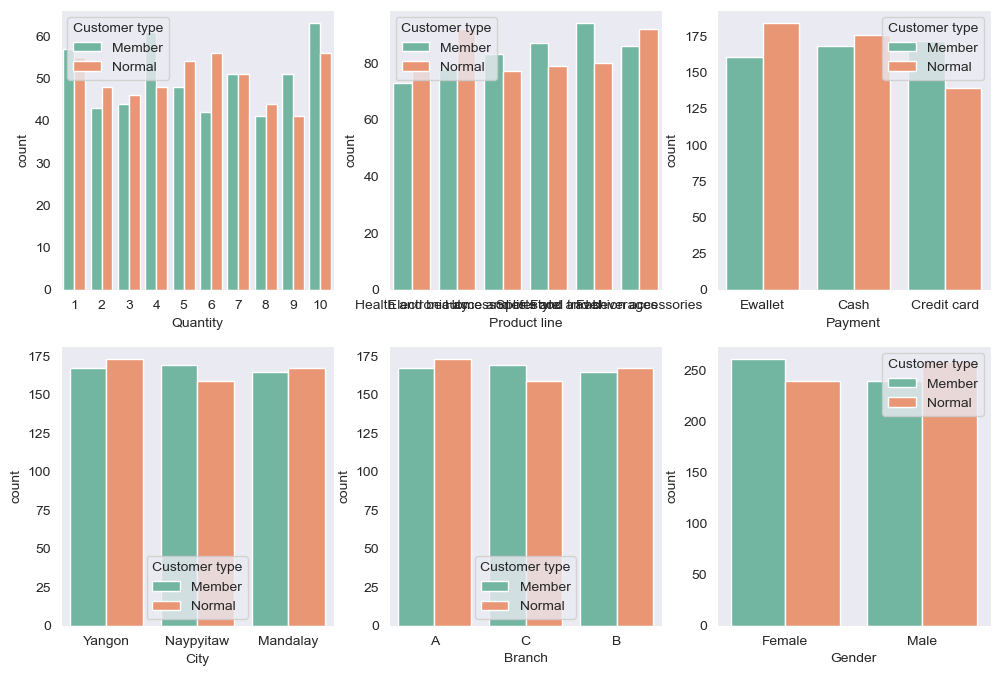

In [47]:
sns.set_style('dark')
sns.set_palette('Set2')
fig,axes=plt.subplots(2,3,figsize=(12,8))

plt.subplot(2,3,1)
sns.countplot(data=supermarket,x=supermarket['Quantity'],hue='Customer type')

plt.subplot(2,3,2)
sns.countplot(data=supermarket,x=supermarket['Product line'],hue='Customer type')

plt.subplot(2,3,3)
sns.countplot(data=supermarket,x=supermarket['Payment'],hue='Customer type')

plt.subplot(2,3,4)
sns.countplot(data=supermarket,x=supermarket['City'],hue='Customer type')

plt.subplot(2,3,5)
sns.countplot(data=supermarket,x=supermarket['Branch'],hue='Customer type')

plt.subplot(2,3,6)
sns.countplot(data=supermarket,x=supermarket['Gender'],hue='Customer type')
plt.show()

In [48]:
objecode=supermarket.select_dtypes(include='object')

<AxesSubplot:xlabel='Quantity', ylabel='Total'>

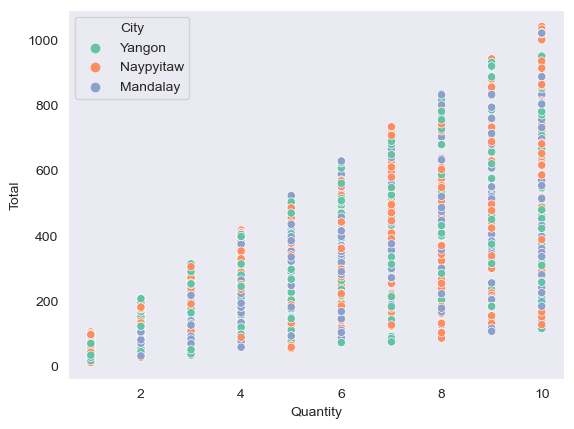

In [49]:
sns.set_style('dark')
sns.scatterplot(data=supermarket,x=supermarket['Quantity']\
,y=supermarket['Total'],hue='City')

In [50]:
from sklearn.preprocessing import LabelEncoder

In [51]:
labelencoder=LabelEncoder()

In [52]:
# encoding the object inputs to numerical inputs
for i in objecode:
    supermarket[i]=labelencoder.fit_transform(supermarket[i])

In [53]:
supermarket.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,814,0,2,0,0,3,74.69,7,26.1415,548.9715,26,146,2,522.83,4.761905,26.1415,9.1
1,142,2,1,1,0,0,15.28,5,3.8200,80.2200,87,23,0,76.40,4.761905,3.8200,9.6
2,653,0,2,1,1,4,46.33,7,16.2155,340.5255,81,155,1,324.31,4.761905,16.2155,7.4
3,18,0,2,0,1,3,58.22,8,23.2880,489.0480,19,485,2,465.76,4.761905,23.2880,8.4
4,339,0,2,1,1,5,86.31,7,30.2085,634.3785,57,29,2,604.17,4.761905,30.2085,5.3
5,733,2,1,1,1,0,85.39,7,29.8865,627.6165,76,393,2,597.73,4.761905,29.8865,4.1
6,315,0,2,0,0,0,68.84,6,20.6520,433.6920,48,214,2,413.04,4.761905,20.6520,5.8
7,264,2,1,1,0,4,73.56,10,36.7800,772.3800,47,77,2,735.60,4.761905,36.7800,8.0
8,702,0,2,0,0,3,36.26,2,3.6260,76.1460,1,341,1,72.52,4.761905,3.6260,7.2
9,726,1,0,0,0,2,54.84,3,8.2260,172.7460,43,159,1,164.52,4.761905,8.2260,5.9


In [54]:
supermarket.dtypes

Invoice ID                   int32
Branch                       int32
City                         int32
Customer type                int32
Gender                       int32
Product line                 int32
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                         int32
Time                         int32
Payment                      int32
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [55]:
# summary statistics of the data
supermarket.describe()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,499.500000,0.988000,1.008000,0.499000,0.499000,2.452000,55.672130,5.510000,15.379369,322.966749,44.582000,251.176000,1.001000,307.58738,4.761905e+00,15.379369,6.97270
std,288.819436,0.817633,0.820127,0.500249,0.500249,1.715412,26.494628,2.923431,11.708825,245.885335,25.894745,147.066923,0.830475,234.17651,6.131498e-14,11.708825,1.71858
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.080000,1.000000,0.508500,10.678500,0.000000,0.000000,0.000000,10.17000,4.761905e+00,0.508500,4.00000
25%,249.750000,0.000000,0.000000,0.000000,0.000000,1.000000,32.875000,3.000000,5.924875,124.422375,21.000000,127.000000,0.000000,118.49750,4.761905e+00,5.924875,5.50000
50%,499.500000,1.000000,1.000000,0.000000,0.000000,2.000000,55.230000,5.000000,12.088000,253.848000,46.000000,248.000000,1.000000,241.76000,4.761905e+00,12.088000,7.00000
75%,749.250000,2.000000,2.000000,1.000000,1.000000,4.000000,77.935000,8.000000,22.445250,471.350250,67.000000,383.000000,2.000000,448.90500,4.761905e+00,22.445250,8.50000
max,999.000000,2.000000,2.000000,1.000000,1.000000,5.000000,99.960000,10.000000,49.650000,1042.650000,88.000000,505.000000,2.000000,993.00000,4.761905e+00,49.650000,10.00000


In [56]:
# relationship/correlation between sets
supermarket.corr()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
Invoice ID,1.000000,-0.041753,0.031247,0.070519,0.023552,0.027589,-0.009213,0.024977,0.027277,0.027277,-0.025614,0.009224,0.021478,0.027277,NaN,0.027277,-0.003787
Branch,-0.041753,1.000000,-0.507401,-0.019608,-0.056318,-0.053938,0.028202,0.015964,0.041047,0.041047,-0.025768,0.035921,-0.050104,0.041047,NaN,0.041047,0.010238
City,0.031247,-0.507401,1.000000,0.004899,0.012219,0.008811,-0.013763,-0.002121,-0.012812,-0.012812,0.002043,-0.066115,0.019094,-0.012812,NaN,-0.012812,0.049585
Customer type,0.070519,-0.019608,0.004899,1.000000,0.039996,-0.036800,-0.020238,-0.016763,-0.019670,-0.019670,-0.000419,-0.020162,0.018073,-0.019670,NaN,-0.019670,0.018889
Gender,0.023552,-0.056318,0.012219,0.039996,1.000000,0.005193,0.015445,-0.074258,-0.049451,-0.049451,0.021450,0.085054,0.044578,-0.049451,NaN,-0.049451,0.004800
Product line,0.027589,-0.053938,0.008811,-0.036800,0.005193,1.000000,0.019321,0.020256,0.031621,0.031621,-0.032970,-0.058607,0.029896,0.031621,NaN,0.031621,-0.020529
Unit price,-0.009213,0.028202,-0.013763,-0.020238,0.015445,0.019321,1.000000,0.010778,0.633962,0.633962,-0.033470,0.008155,-0.015941,0.633962,NaN,0.633962,-0.008778
Quantity,0.024977,0.015964,-0.002121,-0.016763,-0.074258,0.020256,0.010778,1.000000,0.705510,0.705510,-0.013842,-0.009045,-0.003921,0.705510,NaN,0.705510,-0.015815
Tax 5%,0.027277,0.041047,-0.012812,-0.019670,-0.049451,0.031621,0.633962,0.705510,1.000000,1.000000,-0.025537,-0.005298,-0.012434,1.000000,NaN,1.000000,-0.036442
Total,0.027277,0.041047,-0.012812,-0.019670,-0.049451,0.031621,0.633962,0.705510,1.000000,1.000000,-0.025537,-0.005298,-0.012434,1.000000,NaN,1.000000,-0.036442


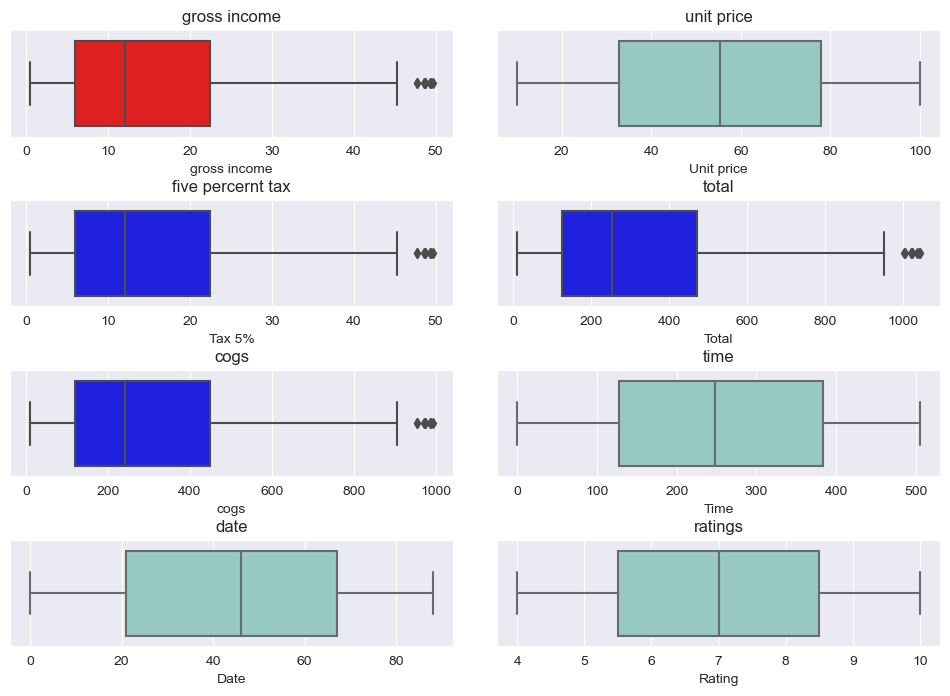

In [57]:
sns.set_style('darkgrid')
sns.set_palette('Set3')
fig,axes=plt.subplots(4,2,figsize=(12,8))

plt.subplot(4,2,1)
sns.boxplot(data=supermarket,x=supermarket['gross income'],color='red')
plt.title('gross income')

plt.subplot(4,2,2)
sns.boxplot(data=supermarket,x=supermarket['Unit price'])
plt.title('unit price')

plt.subplot(4,2,3)
sns.boxplot(data=supermarket,x=supermarket['Tax 5%'],color='blue')
plt.title('five percernt tax')

plt.subplot(4,2,4)
sns.boxplot(data=supermarket,x=supermarket['Total'],color='blue')
plt.title('total')

plt.subplot(4,2,5)
sns.boxplot(data=supermarket,x=supermarket['cogs'],color='blue')
plt.title('cogs')

plt.subplot(4,2,6)
sns.boxplot(data=supermarket,x=supermarket['Time'])
plt.title('time')

plt.subplot(4,2,7)
sns.boxplot(data=supermarket,x=supermarket['Date'])
plt.title('date')

plt.subplot(4,2,8)
sns.boxplot(data=supermarket,x=supermarket['Rating'])
plt.title('ratings')

plt.subplots_adjust(wspace=0.1,hspace=0.6)
plt.show()

In [58]:
# implementing outlier removal
q1=supermarket.quantile(0.25)
q3=supermarket.quantile(0.75)
iqr=q3-q1

In [59]:
print(f'Interquatile range;\n {iqr}')

Interquatile range;
 Invoice ID                 499.500000
Branch                       2.000000
City                         2.000000
Customer type                1.000000
Gender                       1.000000
Product line                 3.000000
Unit price                  45.060000
Quantity                     5.000000
Tax 5%                      16.520375
Total                      346.927875
Date                        46.000000
Time                       256.000000
Payment                      2.000000
cogs                       330.407500
gross margin percentage      0.000000
gross income                16.520375
Rating                       3.000000
dtype: float64


In [60]:
supermarket=supermarket[~((supermarket<(q1-1.5*iqr))|(supermarket>(q3+1.5*iqr)))]

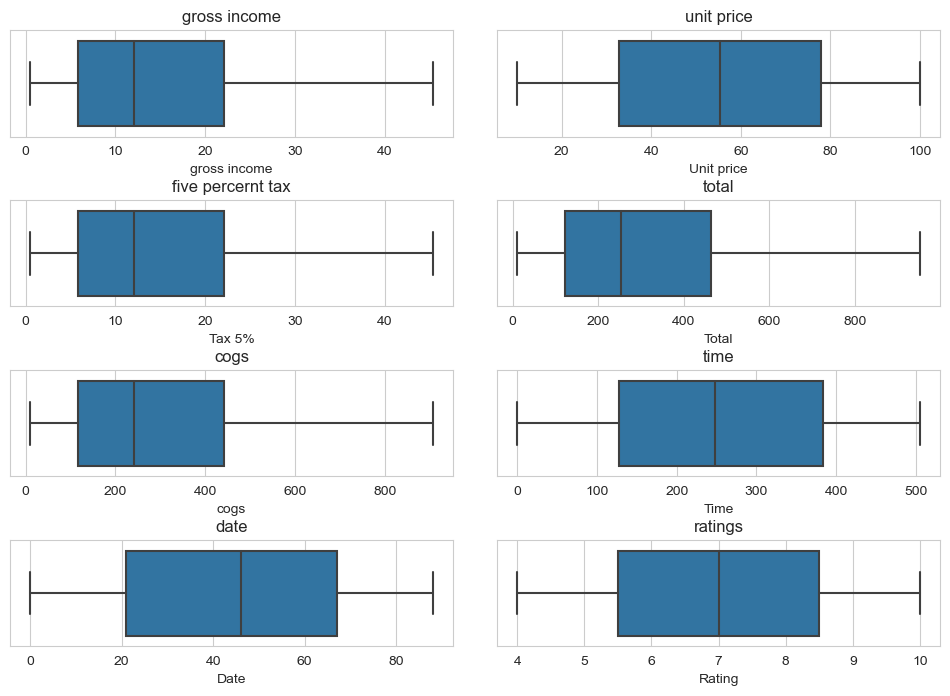

In [61]:
sns.set_style('whitegrid')
sns.set_palette('tab10')
fig,axes=plt.subplots(4,2,figsize=(12,8))

plt.subplot(4,2,1)
sns.boxplot(data=supermarket,x=supermarket['gross income'])
plt.title('gross income')

plt.subplot(4,2,2)
sns.boxplot(data=supermarket,x=supermarket['Unit price'])
plt.title('unit price')

plt.subplot(4,2,3)
sns.boxplot(data=supermarket,x=supermarket['Tax 5%'])
plt.title('five percernt tax')

plt.subplot(4,2,4)
sns.boxplot(data=supermarket,x=supermarket['Total'])
plt.title('total')

plt.subplot(4,2,5)
sns.boxplot(data=supermarket,x=supermarket['cogs'])
plt.title('cogs')

plt.subplot(4,2,6)
sns.boxplot(data=supermarket,x=supermarket['Time'])
plt.title('time')

plt.subplot(4,2,7)
sns.boxplot(data=supermarket,x=supermarket['Date'])
plt.title('date')

plt.subplot(4,2,8)
sns.boxplot(data=supermarket,x=supermarket['Rating'])
plt.title('ratings')

plt.subplots_adjust(wspace=0.1,hspace=0.6)
plt.show()

<AxesSubplot:xlabel='Unit price', ylabel='gross income'>

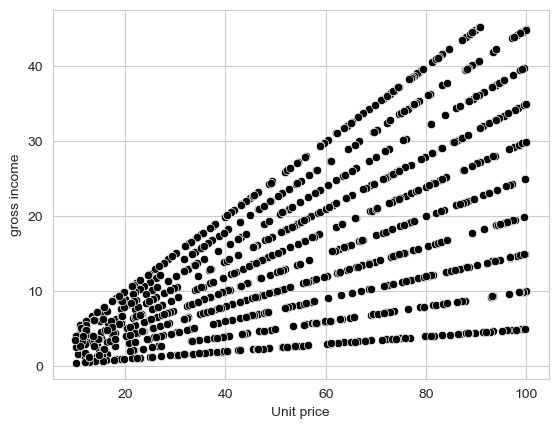

In [62]:
sns.scatterplot(data=supermarket,x=supermarket['Unit price']\
,y=supermarket['gross income'],color='black')

In [63]:
comatrix=supermarket.corr()

<AxesSubplot:>

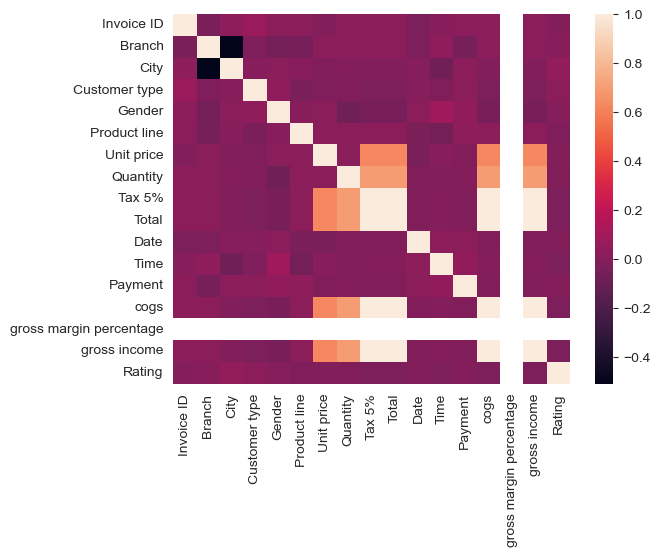

In [64]:
sns.heatmap(comatrix)